<a href="https://colab.research.google.com/github/SalmaAllam8/Brazilian-E-Commerce/blob/main/Notebook/preparing_the_data_for_mysql_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [ ]:
raw_path = '/kaggle/input/brazilian-ecommerce/'
olist_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
olist_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
olist_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
olist_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
olist_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
olist_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')

In [ ]:
# Collections for each dataset
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
data_info = pd.DataFrame({})
data_info['dataset'] = names  # the 8 dataset names
data_info['n_rows'] = [df.shape[0] for df in datasets] # loops over each dataset and gives off the number of rows so 8
data_info['n_cols'] = [df.shape[1] for df in datasets] # loops over each dataset again and gives off the number of each column so 8 too
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets] # calculate the number of null values for every data set so 8 too
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

# selected the columns with null values and counted them for each data set so 8 too
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

# this one appends them together into a string using join  8 too

data_info.style.background_gradient()

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


In [ ]:
orders_date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in orders_date_columns:
    olist_orders[col] = pd.to_datetime(olist_orders[col])

reviews_date_columns = [
    'review_creation_date',
    'review_answer_timestamp'
]

for col in reviews_date_columns:
    olist_order_reviews[col] = pd.to_datetime(olist_order_reviews[col])

In [ ]:
olist_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
olist_products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
missing = olist_products.isnull().sum()
missing_pct = (olist_products.isnull().sum() / len(olist_products)) * 100

summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
})

print(summary[summary['missing_count'] > 0].sort_values('missing_count', ascending=False))

                            missing_count  missing_pct
product_category_name                 610         1.85
product_name_lenght                   610         1.85
product_description_lenght            610         1.85
product_photos_qty                    610         1.85
product_weight_g                        2         0.01
product_length_cm                       2         0.01
product_height_cm                       2         0.01
product_width_cm                        2         0.01


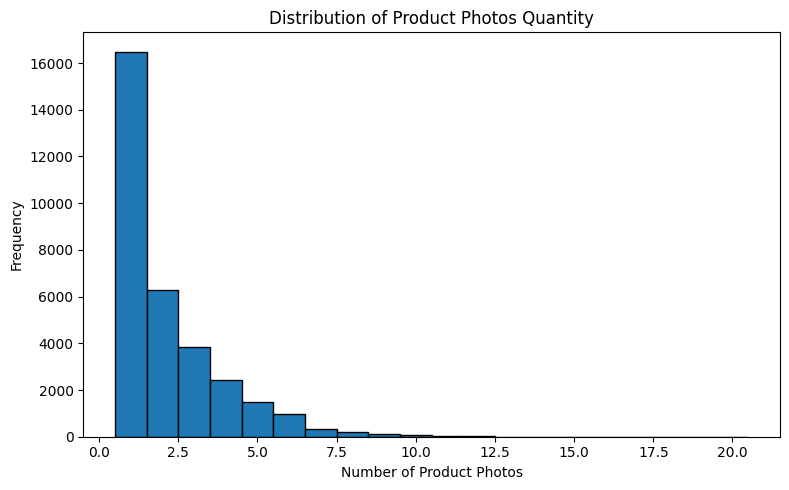

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(olist_products['product_photos_qty'].dropna(), bins=range(1, int(olist_products['product_photos_qty'].max()) + 2),
         edgecolor='black', align='left')
plt.xlabel('Number of Product Photos')
plt.ylabel('Frequency')
plt.title('Distribution of Product Photos Quantity')
plt.tight_layout()
plt.savefig('product_photos_histogram.png', dpi=150)
plt.show()

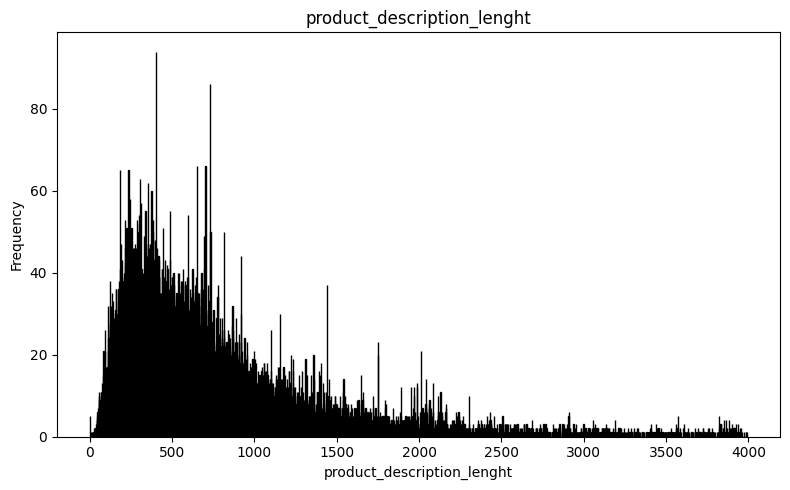

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(olist_products['product_description_lenght'].dropna(), bins=range(1, int(olist_products['product_description_lenght'].max()) + 2),
         edgecolor='black', align='left')
plt.xlabel('product_description_lenght')
plt.ylabel('Frequency')
plt.title('product_description_lenght')
plt.tight_layout()
plt.savefig('product_photos_histogram.png', dpi=150)
plt.show()

In [ ]:
olist_products['product_description_lenght'].describe()

,product_description_lenght
count,32341.000000
mean,771.495285
std,635.115225
min,4.000000
25%,339.000000
50%,595.000000
75%,972.000000
max,3992.000000


In [ ]:
# Fill description length and photo quantity with 0
olist_products['product_description_lenght'] = olist_products['product_description_lenght'].fillna(0)
olist_products['product_photos_qty'] = olist_products['product_photos_qty'].fillna(0)

# Fill physical dimension columns with median
for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    olist_products[col] = olist_products[col].fillna(olist_products[col].median())

# Verify no missing values remain in these columns
cols_check = ['product_description_lenght', 'product_photos_qty',
              'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
print(olist_products[cols_check].isnull().sum())

product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [ ]:
# Check: are these NaNs explained by order_status?
for col in ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']:
    print(f"\n--- Missing '{col}' by order_status ---")
    print(olist_orders[olist_orders[col].isnull()]['order_status'].value_counts())


--- Missing 'order_approved_at' by order_status ---
order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

--- Missing 'order_delivered_carrier_date' by order_status ---
order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

--- Missing 'order_delivered_customer_date' by order_status ---
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


### Conclusion

> Most missing values are **business-related rather than data errors**. They occur because many orders were canceled or did not reach later stages of the fulfillment process, making the corresponding timestamps unavailable by design.

> Only a small number of completed (delivered) orders contain missing timestamps, suggesting minor data quality issues compared with the overall dataset.

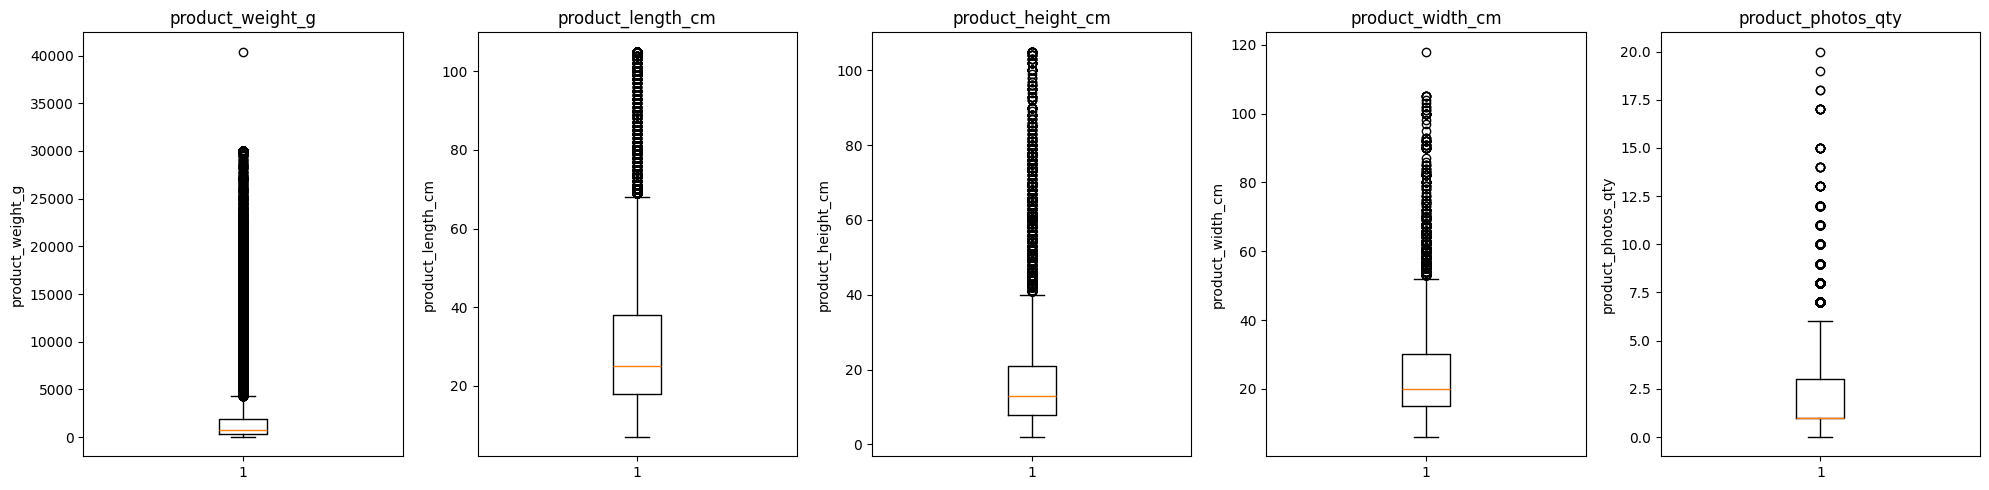

In [ ]:

cols = ['product_weight_g', 'product_length_cm', 'product_height_cm',
        'product_width_cm', 'product_photos_qty']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(cols):
    axes[i].boxplot(olist_products[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('products_boxplots.png', dpi=150)
plt.show()

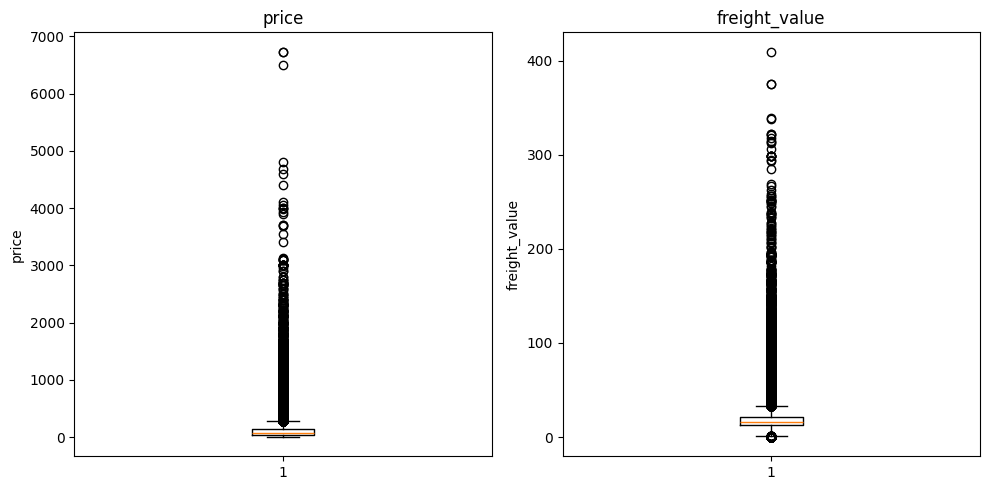

In [ ]:
cols = ['price', 'freight_value']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(cols):
    axes[i].boxplot(olist_order_items[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('order_items_boxplots.png', dpi=150)
plt.show()

In [ ]:
def iqr_outliers(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    print(f"--- {col_name} ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")
    print(f"Percentage of outliers: {len(outliers) / len(series) * 100:.2f}%")
    print(f"Min outlier: {outliers.min():.2f}, Max outlier: {outliers.max():.2f}\n")

    return outliers, lower_bound, upper_bound

price_outliers, price_lower, price_upper = iqr_outliers(olist_order_items['price'].dropna(), 'price')
freight_outliers, freight_lower, freight_upper = iqr_outliers(olist_order_items['freight_value'].dropna(), 'freight_value')

--- price ---
Q1: 39.90, Q3: 134.90, IQR: 95.00
Lower bound: -102.60, Upper bound: 277.40
Number of outliers: 8427
Percentage of outliers: 7.48%
Min outlier: 277.45, Max outlier: 6735.00

--- freight_value ---
Q1: 13.08, Q3: 21.15, IQR: 8.07
Lower bound: 0.98, Upper bound: 33.25
Number of outliers: 12134
Percentage of outliers: 10.77%
Min outlier: 0.00, Max outlier: 409.68



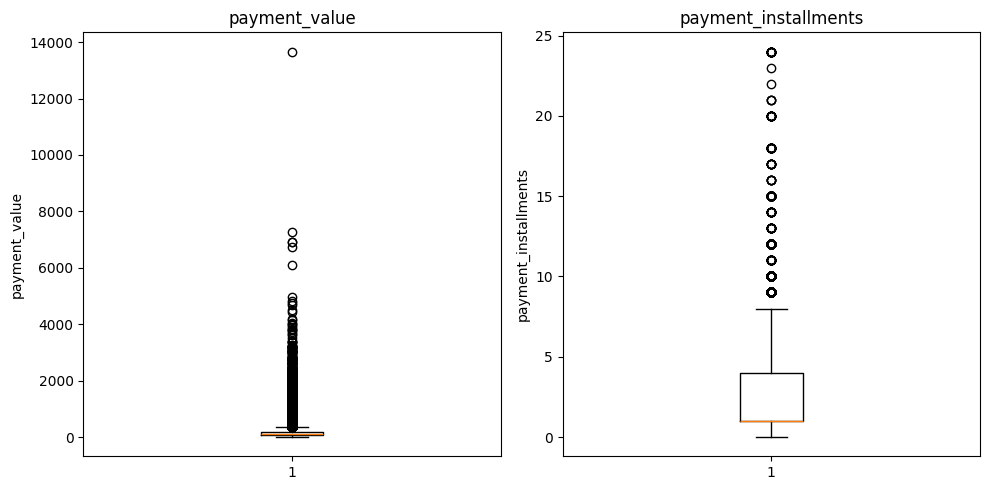

In [ ]:

cols = ['payment_value', 'payment_installments']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i, col in enumerate(cols):
    axes[i].boxplot(olist_order_payments[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('order_payments_boxplots.png', dpi=150)
plt.show()

No outliers were removed from the dataset. The observed variations in product prices and freight costs are expected in an e-commerce environment. High-priced products (e.g., electronics and furniture) and higher shipping costs due to larger items or longer delivery distances represent legitimate business cases rather than anomalies. Therefore, all observations were retained for the analysis.

In [ ]:
import os

os.makedirs("cleaned_data", exist_ok=True)

datasets = {
    "olist_customers_dataset.csv": olist_customer,
    "olist_geolocation_dataset.csv": olist_geolocation,
    "olist_orders_dataset.csv": olist_orders,
    "olist_order_items_dataset.csv": olist_order_items,
    "olist_order_payments_dataset.csv": olist_order_payments,
}

for filename, df in datasets.items():
    df.to_csv(f"cleaned_data/{filename}", index=False)

print("All cleaned datasets have been saved.")

All cleaned datasets have been saved.
